In [119]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dropout, Bidirectional, LSTM, Dense, Concatenate
)
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from IPython.display import clear_output
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.utils import class_weight
import math
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [9]:
results_df = pd.read_table('./data_here/all_results.txt', delimiter='\t')

In [18]:
def get_trial_coords(subitem, df):
    filtered_df = df[df['subitem'] == subitem]
    x_plots = filtered_df['X_coord'].replace('empty', None).astype(float).tolist()
    y_plots = filtered_df['Y_coord'].replace('empty', None).astype(float).tolist()
    return x_plots, y_plots

In [50]:
def get_activity_centroids(item, df):
    item_df = df[df['item'] == item]
    
    a_item_df = item_df[item_df['IntAr'] == 'agent']
    x_mean = pd.to_numeric(a_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(a_item_df['Y_coord'], errors='coerce').mean()
    a_centroid = (x_mean, y_mean)
    
    b_item_df = item_df[item_df['IntAr'] == 'patient']
    x_mean = pd.to_numeric(b_item_df['X_coord'], errors='coerce').mean()
    y_mean = pd.to_numeric(b_item_df['Y_coord'], errors='coerce').mean()
    b_centroid = (x_mean, y_mean)

    return a_centroid, b_centroid

In [48]:
def get_dataset(df):
    complete_df = pd.DataFrame(columns=['subitem', 'item', 'participent_language', 'x_coords', 'y_coords', 'test_accuracy', 'a_dists', 'b_dists'])
    for subitem in df['subitem'].unique():
        a_dists = []
        b_dists = []
        
        item = df.loc[df['subitem'] == subitem, 'item'].unique()[0]
        x_coords, y_coords = get_trial_coords(subitem, df)
        
        a_centroid, b_centroid = get_activity_centroids(item, df)
        for i in range(len(x_coords)):
            a_dists.append(math.dist((x_coords[i], y_coords[i]), a_centroid))
            b_dists.append(math.dist((x_coords[i], y_coords[i]), b_centroid)) 
        
        participent_language = df.loc[df['subitem'] == subitem, 'participant_language'].unique()[0]
        test_accuracy = False if df[df['subitem'] == subitem]['memory_accuracy'].unique()[0] == "incorrect_response" else True

        complete_df.loc[len(complete_df)] = [subitem, item, participent_language, x_coords, y_coords, test_accuracy, a_dists, b_dists]
        
        print(subitem)
        clear_output(wait=True)
        
    return complete_df

In [106]:
#dataset_df = get_dataset(results_df)
dataset_df = pd.read_json("complete_df.json", orient="records", lines=True)

In [109]:
pd.set_option('display.max_columns', None)
dataset_df

,subitem,item,participent_language,x_coords,y_coords,area_order,gaze_shift,distractions,TA_strict_a,TA_strict_b,TA_loose_a,TA_loose_b,ordered,a_dists,b_dists,duration_agent,duration_patient,duration_empty,semantic_relationship,test_accuracy,agent_react_time,patient_react_time,agent_leave_time,patient_leave_time,agent_focus_on_onset,patient_focus_on_onset
0,sub101_1,1,L1_participant,"[484.3, 484.3, 484.3, None, None, 516.4, 516.4...","[131.0, 131.0, 131.0, None, None, 75.6, 75.6, ...",1,3,0,1.000000,0.000000,True,False,True,"[242.5447002468, 242.5447002468, 242.544700246...","[393.478543932, 393.478543932, 393.478543932, ...",3280,380,340,0.538630,False,3.0,556.0,1743.0,976.0,True,False
1,sub101_2,2,L1_participant,"[524.3, 524.3, 524.3, 524.3, 524.3, 524.3, 524...","[77.8, 77.8, 77.8, 77.8, 77.8, 77.8, 77.8, 77....",2,4,0,0.000000,0.000000,False,False,False,"[233.6752744812, 233.6752744812, 233.675274481...","[199.3555174292, 199.3555174292, 199.355517429...",1070,2630,300,0.355066,True,860.0,707.0,1760.0,2157.0,False,False
2,sub101_3,3,L1_participant,"[533.9, 533.9, 533.9, 533.9, 533.9, 533.9, 533...","[105.2, 105.2, 105.2, 105.2, 105.2, 105.2, 105...",1,6,1,0.488372,0.862069,True,True,True,"[238.7393283452, 238.7393283452, 238.739328345...","[359.8102799126, 359.8102799126, 359.810279912...",2180,1050,770,0.195968,True,5.0,87.0,255.0,667.0,True,False
3,sub101_4,4,L1_participant,"[520.3, 520.3, 520.3, 520.3, 520.3, 520.3, 520...","[97.7, 97.7, 97.7, 97.7, 97.7, 97.7, 97.7, 97....",2,8,0,1.000000,0.236364,True,True,False,"[251.9581868243, 251.9581868243, 251.958186824...","[255.5772939853, 255.5772939853, 255.577293985...",2130,990,880,0.657580,False,8.0,66.0,928.0,236.0,True,True
4,sub101_5,5,L1_participant,"[None, None, None, None, None, None, None, Non...","[None, None, None, None, None, None, None, Non...",2,7,1,0.561644,0.388889,True,True,False,"[None, None, None, None, None, None, None, Non...","[None, None, None, None, None, None, None, Non...",1130,1620,1250,0.444074,False,324.0,7.0,804.0,327.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,sub201_18,18,BILINGUAL,"[508.5, 508.5, 508.5, 508.5, 508.5, 508.5, 508...","[99.7, 99.7, 99.7, 99.7, 99.7, 99.7, 99.7, 99....",1,5,0,0.554217,1.000000,True,True,True,"[234.4272562786, 234.4272562786, 234.427256278...","[296.9521333504, 296.9521333504, 296.952133350...",800,2370,830,0.788806,False,212.0,8.0,732.0,1448.0,False,True
4336,sub201_19,19,BILINGUAL,"[514.9, 514.9, 514.9, 514.9, 514.9, 514.9, 514...","[103.6, 103.6, 103.6, 103.6, 103.6, 103.6, 103...",0,1,0,0.000000,1.000000,False,True,False,"[168.2062468331, 168.2062468331, 168.206246833...","[293.2610229093, 293.2610229093, 293.261022909...",0,3630,370,0.471298,True,NaN,5.0,NaN,NaN,False,True
4337,sub201_20,20,BILINGUAL,"[508.0, 508.0, 508.0, 508.0, 508.0, 508.0, 508...","[101.5, 101.5, 101.5, 101.5, 101.5, 101.5, 101...",1,5,0,0.084746,0.375000,True,True,True,"[191.9479227499, 191.9479227499, 191.947922749...","[354.9737743575, 354.9737743575, 354.973774357...",2490,540,970,0.618740,True,1.0,9.0,111.0,399.0,True,True
4338,sub201_21,21,BILINGUAL,"[512.7, 512.7, 512.7, 512.7, 512.7, 512.7, 512...","[106.7, 106.7, 106.7, 106.7, 106.7, 106.7, 106...",1,3,0,0.000000,1.000000,False,True,True,"[212.5053806515, 212.5053806515, 212.505380651...","[392.1009345715, 392.1009345715, 392.100934571...",740,2900,360,0.685809,False,2881.0,7.0,NaN,1497.0,False,True


In [114]:
sequence_length = 350
sequence_cols = ['x_coords', 'y_coords', 'a_dists', 'b_dists']
static_columns = [
    'participent_language', 'area_order', 'gaze_shift', 'distractions',
    'TA_strict_a', 'TA_strict_b', 'TA_loose_a', 'TA_loose_b',
    'duration_agent', 'duration_patient', 'duration_empty',
    'agent_react_time', 'patient_react_time',
    'agent_leave_time', 'patient_leave_time',
    'agent_focus_on_onset', 'patient_focus_on_onset'
]

# Sequence processing
def safe_parse_array(arr):
    if isinstance(arr, str):
        arr = eval(arr)
    return arr

for col in sequence_cols:
    dataset_df[col] = dataset_df[col].apply(safe_parse_array)

valid_rows = dataset_df.apply(
    lambda row: all(pd.notna(row[col]).any() for col in sequence_cols),
    axis=1
)
dataset_df = dataset_df[valid_rows].copy()

sequences = []
labels = []

for _, row in dataset_df.iterrows():
    x = np.array(row['x_coords'], dtype=np.float32)
    y = np.array(row['y_coords'], dtype=np.float32)
    a = np.array(row['a_dists'], dtype=np.float32)
    b = np.array(row['b_dists'], dtype=np.float32)

    valid_mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(a) & ~np.isnan(b)
    if not np.any(valid_mask): continue

    x, y, a, b = x[valid_mask], y[valid_mask], a[valid_mask], b[valid_mask]

    def norm(arr): return (arr - np.mean(arr)) / np.std(arr) if np.std(arr) > 0 else arr - np.mean(arr)
    features = np.stack([norm(x), norm(y), norm(a), norm(b)], axis=-1)
    sequences.append(features)
    labels.append(int(row['test_accuracy']))

X_seq = pad_sequences(sequences, maxlen=sequence_length, dtype='float32', padding='post', truncating='post')
y = np.array(labels, dtype=np.int32)

# Static feature processing
categorical_cols = ['participent_language']
numeric_cols = [col for col in static_columns if col not in categorical_cols]

dataset_df[numeric_cols] = dataset_df[numeric_cols].fillna(0)
dataset_df[categorical_cols] = dataset_df[categorical_cols].fillna('missing')

for col in numeric_cols:
    if dataset_df[col].dtype == 'bool':
        dataset_df[col] = dataset_df[col].astype(int)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_features = ohe.fit_transform(dataset_df[categorical_cols])

scaler = StandardScaler()
numeric_features = scaler.fit_transform(dataset_df[numeric_cols])

X_static = np.hstack([categorical_features, numeric_features])

# Train test split
X_seq_train, X_seq_test, X_static_train, X_static_test, y_train, y_test = train_test_split(
    X_seq, X_static, y, test_size=0.2, stratify=y, random_state=42
)

# compute class weights
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))

In [115]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Model definition
sequence_input = Input(shape=(sequence_length, 4), name='sequence_input')
static_input = Input(shape=(X_static.shape[1],), name='static_input')

x = Conv1D(64, kernel_size=5, activation='relu')(sequence_input)
x = Dropout(0.2)(x)
x = Conv1D(64, kernel_size=3, activation='relu')(x)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(32))(x)
x = Dropout(0.2)(x)

s = Dense(64, activation='relu')(static_input)
s = Dropout(0.3)(s)

combined = Concatenate()([x, s])
combined = Dense(64, activation='relu')(combined)
combined = Dropout(0.3)(combined)
output = Dense(1, activation='sigmoid')(combined)

model = Model(inputs=[sequence_input, static_input], outputs=output)


In [117]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train
history = model.fit(
    [X_seq_train, X_static_train],
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
y_pred_probs = model.predict([X_seq_test, X_static_test]).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_test, y_pred, zero_division=0))

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 25s 255ms/step - accuracy: 0.6043 - loss: 0.6826 - val_accuracy: 0.5151 - val_loss: 0.6968
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 25s 290ms/step - accuracy: 0.4997 - loss: 0.7038 - val_accuracy: 0.5813 - val_loss: 0.6785
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - accuracy: 0.5869 - loss: 0.6804 - val_accuracy: 0.4374 - val_loss: 0.7182
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 25s 292ms/step - accuracy: 0.5707 - loss: 0.6744 - val_accuracy: 0.5165 - val_loss: 0.6955
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 294ms/step - accuracy: 0.5147 - loss: 0.6972 - val_accuracy: 0.5525 - val_loss: 0.6877
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 296ms/step - accuracy: 0.5574 - loss: 0.6817 - val_accuracy: 0.5640 - val_loss: 0.6859
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 298ms/step - accuracy: 0.5827 - loss: 0.6821 - val_accuracy: 0.5122 - val_loss: 0.6968
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
28/28 ━━━━━━━━

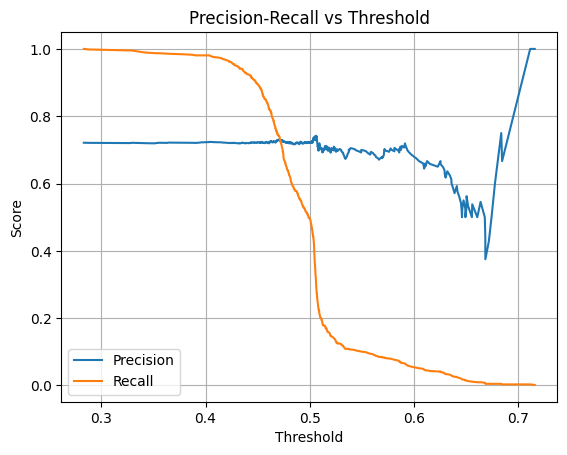

In [77]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_probs)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

for col in ['x_coords', 'y_coords', 'a_dists', 'b_dists']:
    dataset_df[col] = dataset_df[col].apply(safe_parse_array)

# Filter out rows where all 4 are invalid or empty
valid_rows = dataset_df.apply(
    lambda row: all(pd.notna(row[col]).any() for col in ['x_coords', 'y_coords', 'a_dists', 'b_dists']),
    axis=1
)
dataset_df = dataset_df[valid_rows].copy()


sequences = []
labels = []

for _, row in dataset_df.iterrows():
    x = np.array(row['x_coords'], dtype=np.float32)
    y = np.array(row['y_coords'], dtype=np.float32)
    a = np.array(row['a_dists'], dtype=np.float32)
    b = np.array(row['b_dists'], dtype=np.float32)

    # Keep only valid timesteps where all 4 are present
    valid_mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(a) & ~np.isnan(b)
    x = x[valid_mask]
    y = y[valid_mask]
    a = a[valid_mask]
    b = b[valid_mask]

    if len(x) == 0:
        continue

    # Normalize
    def normalize(arr):
        return (arr - np.mean(arr)) / np.std(arr) if np.std(arr) > 0 else arr - np.mean(arr)

    x = normalize(x)
    y = normalize(y)
    a = normalize(a)
    b = normalize(b)

    # Stack to shape (timesteps, 4)
    features = np.stack([x, y, a, b], axis=-1)
    sequences.append(features)
    labels.append(int(row['test_accuracy']))

# Pad to fixed length
sequence_length = 350
X = pad_sequences(sequences, maxlen=sequence_length, dtype='float32', padding='post', truncating='post')
y = np.array(labels, dtype=np.int32)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [94]:
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(sequence_length, 4)),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    Dropout(0.2),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),   # First LSTM layer (outputs full sequence)
    Dropout(0.2),
    Bidirectional(LSTM(32, return_sequences=False)),  # Second LSTM layer (outputs last hidden state)
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])


In [99]:
import tensorflow as tf
from tensorflow.keras import backend as K

def binary_focal_loss(gamma=2.0, alpha=0.25, scale=10.0):
    def focal_loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))

        loss_1 = -alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1)
        loss_0 = -(1 - alpha) * K.pow(pt_0, gamma) * K.log(1. - pt_0)

        return scale * K.mean(loss_1 + loss_0)

    return focal_loss


In [104]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    loss=binary_focal_loss(gamma=2.0, alpha=0.25),
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',     # or'val_accuracy'
    patience=10,             # Wait 5 epochs after no improvement
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,           
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)


# Evaluate
y_pred_probs = model.predict(X_test).flatten()
y_pred = (y_pred_probs > 0.47).astype(int)

print(classification_report(y_test, y_pred))

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.3345 - loss: 0.6798 - val_accuracy: 0.3755 - val_loss: 0.6968
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.3968 - loss: 0.6767 - val_accuracy: 0.4230 - val_loss: 0.6922
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.4642 - loss: 0.6566 - val_accuracy: 0.3583 - val_loss: 0.7098
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.4273 - loss: 0.6730 - val_accuracy: 0.5237 - val_loss: 0.7455
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.5489 - loss: 0.6421 - val_accuracy: 0.4302 - val_loss: 0.7193
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - accuracy: 0.4071 - loss: 0.6726 - val_accuracy: 0.4446 - val_loss: 0.7136
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.4561 - loss: 0.6611 - val_accuracy: 0.4417 - val_loss: 0.7588
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.5082 - loss: 0.6624 - val_accur

In [105]:
model.compile(
    loss=binary_focal_loss(gamma=2.0, alpha=0.25),
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',     # or'val_accuracy'
    patience=10,             # Wait 5 epochs after no improvement
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,           
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)


# Evaluate
y_pred_probs = model.predict(X_test).flatten()
y_pred = (y_pred_probs > 0.47).astype(int)

print(classification_report(y_test, y_pred))

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.5319 - loss: 0.6439 - val_accuracy: 0.3036 - val_loss: 0.6901
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.4076 - loss: 0.6765 - val_accuracy: 0.3770 - val_loss: 0.6983
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.4357 - loss: 0.6523 - val_accuracy: 0.3612 - val_loss: 0.7198
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.4662 - loss: 0.6611 - val_accuracy: 0.3640 - val_loss: 0.7113
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.3783 - loss: 0.6592 - val_accuracy: 0.3827 - val_loss: 0.7560
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.4802 - loss: 0.6513 - val_accuracy: 0.4518 - val_loss: 0.7005
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.4876 - loss: 0.6680 - val_accuracy: 0.3669 - val_loss: 0.7234
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.4464 - loss: 0.6588 - val_accura

In [125]:
sequence_length = 350
sequence_cols = ['x_coords', 'y_coords', 'a_dists', 'b_dists']
static_columns = [
    'test_accuracy',
    'area_order', 'gaze_shift', 'distractions',
    'TA_strict_a', 'TA_strict_b', 'TA_loose_a', 'TA_loose_b',
    'duration_agent', 'duration_patient', 'duration_empty',
    'agent_react_time', 'patient_react_time',
    'agent_leave_time', 'patient_leave_time',
    'agent_focus_on_onset', 'patient_focus_on_onset'
]

# Sequence preprocessing 
def safe_parse_array(arr):
    if isinstance(arr, str):
        arr = eval(arr)
    return arr

for col in sequence_cols:
    dataset_df[col] = dataset_df[col].apply(safe_parse_array)

valid_rows = dataset_df.apply(
    lambda row: all(pd.notna(row[col]).any() for col in sequence_cols),
    axis=1
)
dataset_df = dataset_df[valid_rows].copy()

sequences = []
labels = []

for _, row in dataset_df.iterrows():
    x = np.array(row['x_coords'], dtype=np.float32)
    y = np.array(row['y_coords'], dtype=np.float32)
    a = np.array(row['a_dists'], dtype=np.float32)
    b = np.array(row['b_dists'], dtype=np.float32)

    valid_mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isnan(a) & ~np.isnan(b)
    if not np.any(valid_mask): continue

    x, y, a, b = x[valid_mask], y[valid_mask], a[valid_mask], b[valid_mask]

    def norm(arr): return (arr - np.mean(arr)) / np.std(arr) if np.std(arr) > 0 else arr - np.mean(arr)
    features = np.stack([norm(x), norm(y), norm(a), norm(b)], axis=-1)
    sequences.append(features)
    labels.append(row['participent_language'])

X_seq = pad_sequences(sequences, maxlen=sequence_length, dtype='float32', padding='post', truncating='post')

# Encode labels (participant_language)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)           # [0, 1, 2]
y_categorical = to_categorical(y_encoded)                 # one-hot

# Static feature preprocessing 
numeric_cols = static_columns

dataset_df[numeric_cols] = dataset_df[numeric_cols].fillna(0)
for col in numeric_cols:
    if dataset_df[col].dtype == 'bool':
        dataset_df[col] = dataset_df[col].astype(int)

scaler = StandardScaler()
X_static = scaler.fit_transform(dataset_df[numeric_cols])

# Train test split
X_seq_train, X_seq_test, X_static_train, X_static_test, y_train, y_test = train_test_split(
    X_seq, X_static, y_categorical, test_size=0.2, stratify=y_categorical, random_state=42
)


In [126]:
# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Model definition
sequence_input = Input(shape=(sequence_length, 4), name='sequence_input')
static_input = Input(shape=(X_static.shape[1],), name='static_input')

x = Conv1D(64, kernel_size=5, activation='relu')(sequence_input)
x = Dropout(0.2)(x)
x = Conv1D(64, kernel_size=3, activation='relu')(x)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.2)(x)
x = Bidirectional(LSTM(32))(x)
x = Dropout(0.2)(x)

s = Dense(64, activation='relu')(static_input)
s = Dropout(0.3)(s)

combined = Concatenate()([x, s])
combined = Dense(64, activation='relu')(combined)
combined = Dropout(0.3)(combined)
output = Dense(y_categorical.shape[1], activation='softmax')(combined)

model = Model(inputs=[sequence_input, static_input], outputs=output)


In [128]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train
history = model.fit(
    [X_seq_train, X_static_train],
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
y_pred_probs = model.predict([X_seq_test, X_static_test])
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_true_labels = label_encoder.inverse_transform(y_true)

print(classification_report(y_true_labels, y_pred_labels, zero_division=0))

Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 24s 242ms/step - accuracy: 0.4386 - loss: 1.1051 - val_accuracy: 0.3583 - val_loss: 1.0984
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 25s 290ms/step - accuracy: 0.3952 - loss: 1.0760 - val_accuracy: 0.3209 - val_loss: 1.1228
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 293ms/step - accuracy: 0.3828 - loss: 1.0709 - val_accuracy: 0.2950 - val_loss: 1.1152
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 296ms/step - accuracy: 0.3578 - loss: 1.0745 - val_accuracy: 0.3252 - val_loss: 1.1077
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 296ms/step - accuracy: 0.3911 - loss: 1.0759 - val_accuracy: 0.3899 - val_loss: 1.0845
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 294ms/step - accuracy: 0.4331 - loss: 1.0612 - val_accuracy: 0.3914 - val_loss: 1.0911
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 296ms/step - accuracy: 0.4530 - loss: 1.0584 - val_accuracy: 0.3482 - val_loss: 1.1088
Epoch 8/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 25s 291ms/step - accuracy: 0.4046 - loss: 1.0688 - val_accu

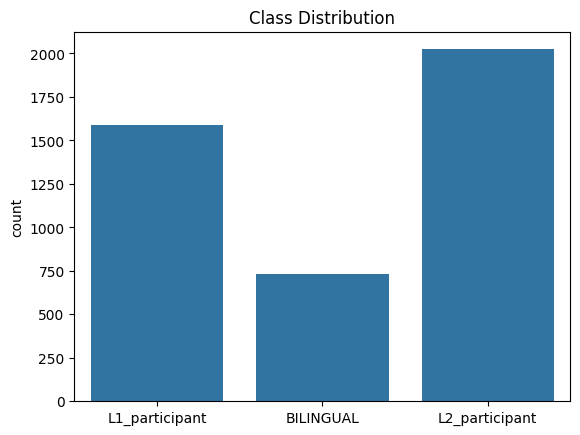

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=label_encoder.inverse_transform(y_encoded))
plt.title("Class Distribution")
plt.show()